       Order_ID  Order_Date   Region       City Customer_Type  \
0        200000   6/25/2021     East  Ahmedabad           New   
1        200001   7/16/2021     East    Kolkata     Returning   
2        200002   6/22/2022  Central       Pune           New   
3        200003   5/18/2022    South       Pune           New   
4        200004    8/3/2022  Central      Delhi     Returning   
...         ...         ...      ...        ...           ...   
51995    233582  11/17/2021    South  Bengaluru           New   
51996    231702   7/20/2021    North  Hyderabad           NaN   
51997    238237   6/25/2021      NaN      Delhi           New   
51998    222358  10/22/2022    North    Kolkata           New   
51999    248246   4/20/2021    North  Bengaluru           New   

      Product_Category  Quantity  Unit_Price  Discount_Percent      Revenue  
0             Clothing       1.0     1371.52               5.0    1302.9440  
1                 Food       6.0     3343.51               0.0 

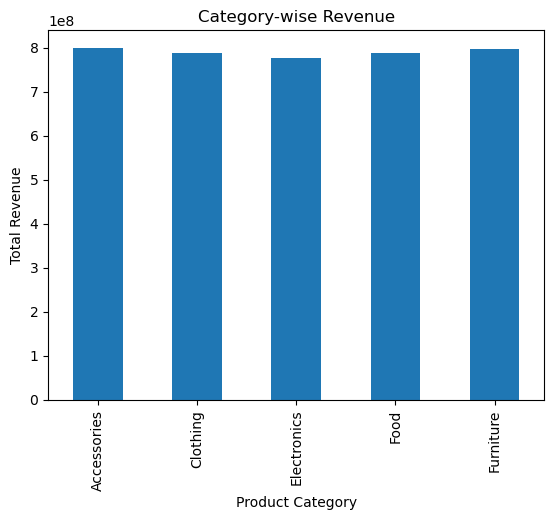

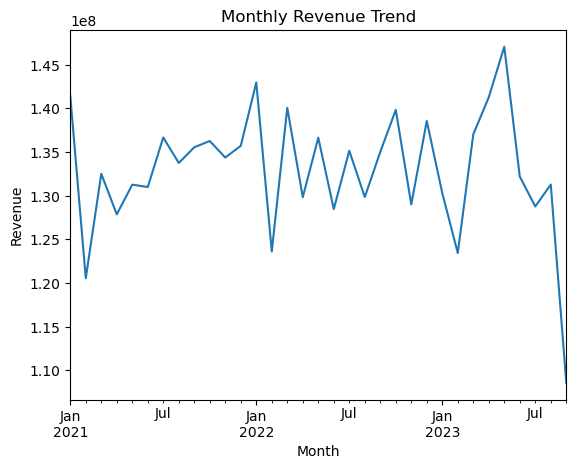

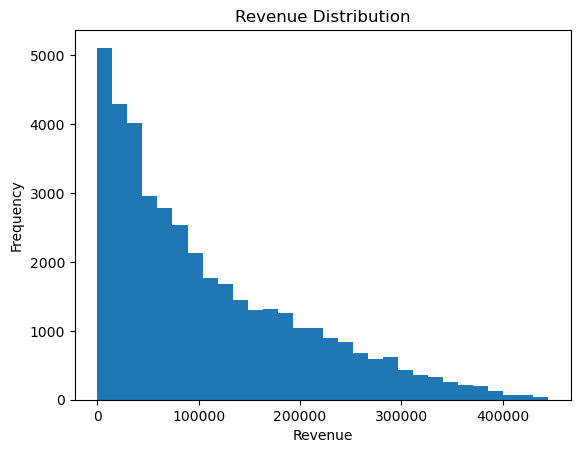

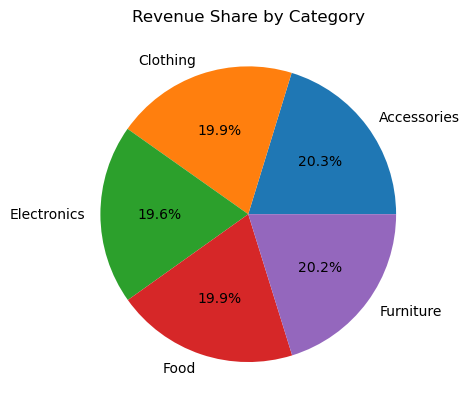

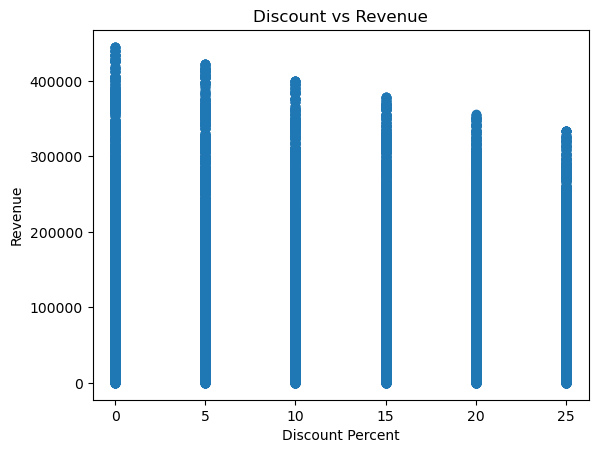

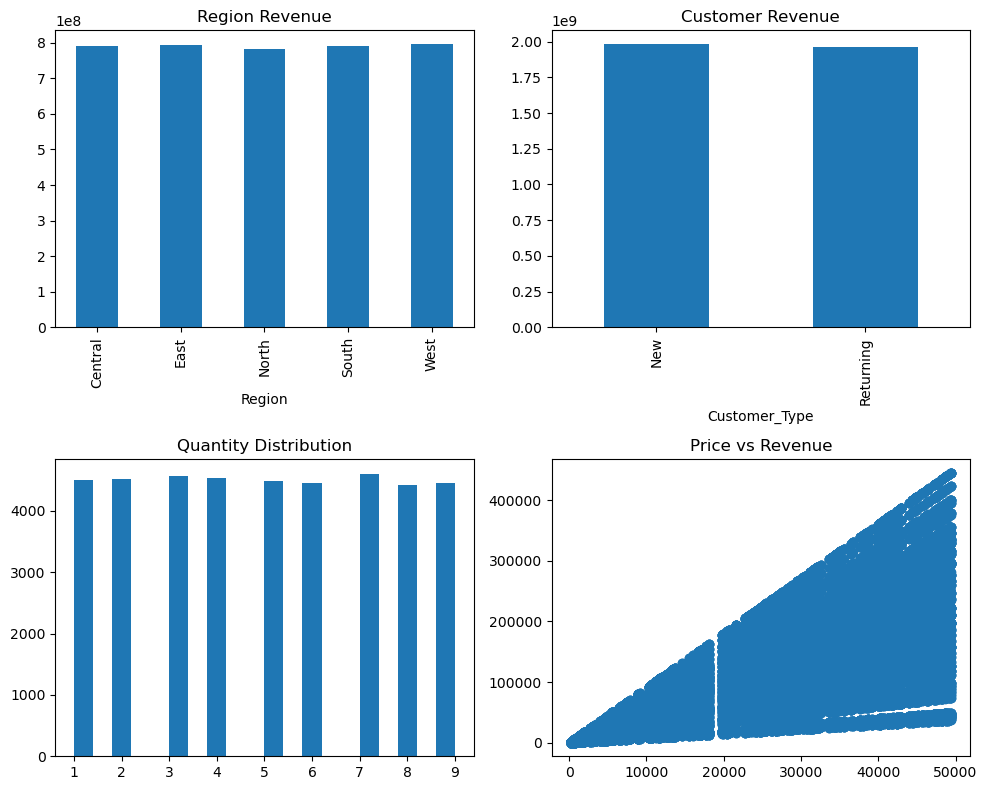


 Key Insights:
1. Highest revenue comes from: West
2. Best selling category: Accessories
3. More revenue from: New customers
4. Peak sales month: 2023-05
5. Discount has moderate impact on revenue

 Business Recommendations:
- Focus on high performing regions and categories
- Retain returning customers
- Use discounts strategically
- Improve low-performing regions
- Plan inventory based on monthly trends


In [4]:
# Indian Retail Business Sales Analysis
# Name: _________prerita morashiya__________
# GR ID: ________10580__________
# Date: 24-01-2026

# ===========================
# Task 1 = Import Libraries
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Task 1 = Load Dataset
# ==============================
file_path = "Indian_Retail_Business_Sales_Gigantic_Dataset.csv"

df = pd.read_csv(r"C:\Users\Admin\Downloads\Indian_Retail_Business_Sales_Gigantic_Dataset.csv")
print(df)
print("====================load dataset sucessfully=======================")

# Display shape
print("Dataset Shape:", df.shape)

# First 5 rows
print("\nFirst 5 Rows:")
print(df.head())

# Last 5 rows
print("\nLast 5 Rows:")
print(df.tail())

# ===========================
# Task 2 = Data Cleaning & EDA
# ===========================


print("\nMissing Values:")    # Check missing values
print(df.isnull().sum())


print("\nDuplicate Rows:", df.duplicated().sum())  # Remove duplicates
df = df.drop_duplicates()


df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')   # Convert Order_Date to datetime

# Data types

print("\nData Types:")
print(df.dtypes)

# Summary statistics

print("\nSummary Statistics:")
print(df.describe())

# Category Distributions

print("\nRegion Distribution:")
print(df['Region'].value_counts())

print("\nProduct Category Distribution:")
print(df['Product_Category'].value_counts())

print("\nCustomer Type Distribution:")
print(df['Customer_Type'].value_counts())

# =================================
# Task 3 = Business Analysis
# ==================================
#-----------------------------1 - Region-wise Revenue---------------------------------------------
region_revenue = df.groupby('Region')['Revenue'].sum()
print("\nRegion-wise Revenue:")
print(region_revenue)

#------------------------------ 2 - Category-wise Revenue-----------------------------------------
category_revenue = df.groupby('Product_Category')['Revenue'].sum()
print("\nCategory-wise Revenue:")
print(category_revenue)

# --------------------------3 - Customer Type Comparison-----------------------------------------
customer_revenue = df.groupby('Customer_Type')['Revenue'].sum()
print("\nCustomer Type Revenue:")
print(customer_revenue)

# ---------------------------4 - Monthly Sales Trend-----------------------------------------
df['Month'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Revenue'].sum()
print("\nMonthly Sales:")
print(monthly_sales)

#------------------------- 5 - Discount vs Revenue------------------------------------------
print("\nDiscount vs Revenue Correlation:")
print(df[['Discount_Percent','Revenue']].corr())

# =============================
# Task 4 = Data Visualization
# =============================

# 1. Bar Chart
plt.figure()
category_revenue.plot(kind='bar')        #Category vs Revenue
plt.title("Category-wise Revenue")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

# 2. Line Chart
plt.figure()
monthly_sales.plot()
plt.title("Monthly Revenue Trend")        #Monthly Sales Trend
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# 3. Histogram 
plt.figure()
plt.hist(df['Revenue'], bins=30)         #Revenue Distribution
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

# 4. Pie Chart
plt.figure()
category_revenue.plot(kind='pie', autopct='%1.1f%%')     #Category Proportion
plt.title("Revenue Share by Category")
plt.ylabel("")
plt.show()

# 5. Scatter Plot
plt.figure()
plt.scatter(df['Discount_Percent'], df['Revenue'])      #Discount vs Revenue
plt.title("Discount vs Revenue")
plt.xlabel("Discount Percent")
plt.ylabel("Revenue")
plt.show()

# 6. Subplots
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
region_revenue.plot(kind='bar')
plt.title("Region Revenue")

plt.subplot(2,2,2)
customer_revenue.plot(kind='bar')
plt.title("Customer Revenue")

plt.subplot(2,2,3)
plt.hist(df['Quantity'], bins=20)
plt.title("Quantity Distribution")

plt.subplot(2,2,4)
plt.scatter(df['Unit_Price'], df['Revenue'])
plt.title("Price vs Revenue")

plt.tight_layout()
plt.show()

# ============================
# Task 5 = Final Insights
# ============================

print("\n Key Insights:")
print("1. Highest revenue comes from:", region_revenue.idxmax())
print("2. Best selling category:", category_revenue.idxmax())
print("3. More revenue from:", customer_revenue.idxmax(), "customers")
print("4. Peak sales month:", monthly_sales.idxmax())
print("5. Discount has moderate impact on revenue")

print("\n @ Business Recommendations:")
print("* Retain returning customers")
print("* Focus on high performing regions and categories")
print("* Use discounts")
print("* Improve low-performing regions")
print("* Plan inventory based on monthly trends")
